In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)
from catboost import CatBoostClassifier, Pool



sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'no': '#e07b54', 'yes': '#378add'}


df_path = r"C:\Users\divye\Data_science_projects\5qaNUcRSLjHZ5anY\data\term-deposit-marketing-2020.csv"

df = pd.read_csv(df_path)

df.head(10)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  str  
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  str  
 7   loan       40000 non-null  str  
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  str  
dtypes: int64(5), str(9)
memory usage: 4.3 MB


In [3]:
eda_df = df.copy()
eda_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='str')

# Feature Engineering

In [4]:
eda_df['age_group'] = pd.cut(eda_df['age'],
    bins=[17, 25, 40, 65, 100],
    labels=['18-25', '26-40', '41-65', '65+'])


# cellular contact + high balance = premium target
eda_df['cellular_wealthy'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['balance'] > 1000)
).astype(int)

# good month + cellular = ideal timing + channel
eda_df['prime_contact'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['month'].isin(['mar', 'oct', 'apr']))
).astype(int)

# no debt + high balance = financially free client
eda_df['financially_free'] = (
    (eda_df['housing'] == 'no') &
    (eda_df['loan'] == 'no') &
    (eda_df['balance'] > 500)
).astype(int)

# tier 1 — high quality months (rate > 10% with meaningful volume)
# tier 2 — medium months (rate 6-10% or high volume)
# tier 3 — poor months (rate < 6% or no data)

month_tier_map = {
    'apr': 1, 'feb': 1,           # good rate + volume
    'mar': 1, 'oct': 1,           # exceptional rate (keep despite low volume)
    'dec': 2,                      # okay rate, low volume
    'jun': 2, 'aug': 2, 'nov': 2, # average
    'jan': 3, 'may': 3,           # worst ROI
    'jul': 3, 'sep': 3            # poor or no data
}

eda_df['month_tier'] = eda_df['month'].map(month_tier_map)

# based on day chart analysis
HIGH_DAYS   = [2, 4, 5, 10, 17, 21, 30]   # rate up + volume present
MEDIUM_DAYS = [3, 6, 7, 8, 14, 15, 16, 20]
AVOID_DAYS  = [19, 22, 23, 24, 25, 29, 31]

eda_df['day_tier'] = eda_df['day'].apply(
    lambda d: 1 if d in HIGH_DAYS
    else 2 if d in MEDIUM_DAYS
    else 3
)

# combined timing score
# logic: good month AND good day = prime window
#        good month AND bad day  = still worth trying
#        bad month  AND good day = marginal
#        bad month  AND bad day  = avoid

eda_df['timing_score'] = eda_df.apply(
    lambda row: (
        # both good — prime window
        1 if row['month_tier'] == 1 and row['day_tier'] == 1
        # month good, day average
        else 2 if row['month_tier'] == 1 and row['day_tier'] == 2
        # month average, day good
        else 3 if row['month_tier'] == 2 and row['day_tier'] == 1
        # both average
        else 4 if row['month_tier'] == 2 and row['day_tier'] == 2
        # anything involving poor month or poor day
        else 5
    ), axis=1
)
# if timing_score = 1 is prime and 5 is worst
# LR sees higher number = worse → negative coefficient
# flip it so higher number = better

eda_df['timing_score_inv'] = 6 - eda_df['timing_score']
# now 5 = prime window, 1 = avoid
# this should flip the coefficient from red to green
# the three conditions that together give the highest
# reliable signal — cellular + young or senior + not married 26-40

def prime_trio(row):
    age     = str(row['age_group'])
    contact = str(row['contact'])
    marital = str(row['marital'])

    # tier 1 — gold combinations
    if age == '65+' and contact == 'cellular':
        return 3   # 50% rate

    if age == '18-25' and contact == 'cellular':
        return 3   # 20% rate

    if age == '65+' and marital in ['married', 'divorced']:
        return 3   # 39-65% rate

    # tier 2 — good combinations
    if contact == 'cellular' and age == '26-40':
        return 2   # 9.2% rate

    if age == '18-25' and marital == 'single':
        return 2   # 14.4% rate

    # tier 3 — dead zones
    if contact == 'unknown':
        return 0   # 3-5% across all groups

    if age == '41-65' and marital == 'married':
        return 0   # 5.7% — below base rate

    # everything else
    return 1

eda_df['prime_trio'] = eda_df.apply(prime_trio, axis=1)

prime_months = ['mar', 'apr', 'oct', 'feb']

eda_df['cellular_prime_month'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['month'].isin(prime_months))
).astype(int)

# Logistic Regression(Train-Test Split)

   Logistic Regression — DUAL RECALL THRESHOLD TUNING
   Active set       : raw + engineered | no duration | no campaign
   YES recall floor : 80%
   NO  recall floor : 50%

Features in use (7) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']

Categorical cols (4) : ['marital', 'housing', 'contact', 'month']
Numeric cols    (3) : ['day', 'age', 'balance']

Features after one-hot encoding : 18

Train : 32000 rows (yes: 2317, no: 29683)
Test  : 8000 rows (yes: 579,  no: 7421)

Class weight : 'balanced'  (no=29683, yes=2317)
Model trained ✓
ROC-AUC : 0.7046

   THRESHOLD SCAN — YES recall vs NO recall trade-off
   ✅ = meets both floors (YES≥80% AND NO≥50%)
   Thresh  YES rec   NO rec  YES prec   YES F1    FN     FP
------------------------------------------------------------------------------
      0.05     99.8%     0.0%      7.2%    13.5%     1   7420
      0.06     99.8%     0.0%      7.2%    13.5%     1   7420
      0.07     99.8%     0.0%      7.2%    13.5%     1

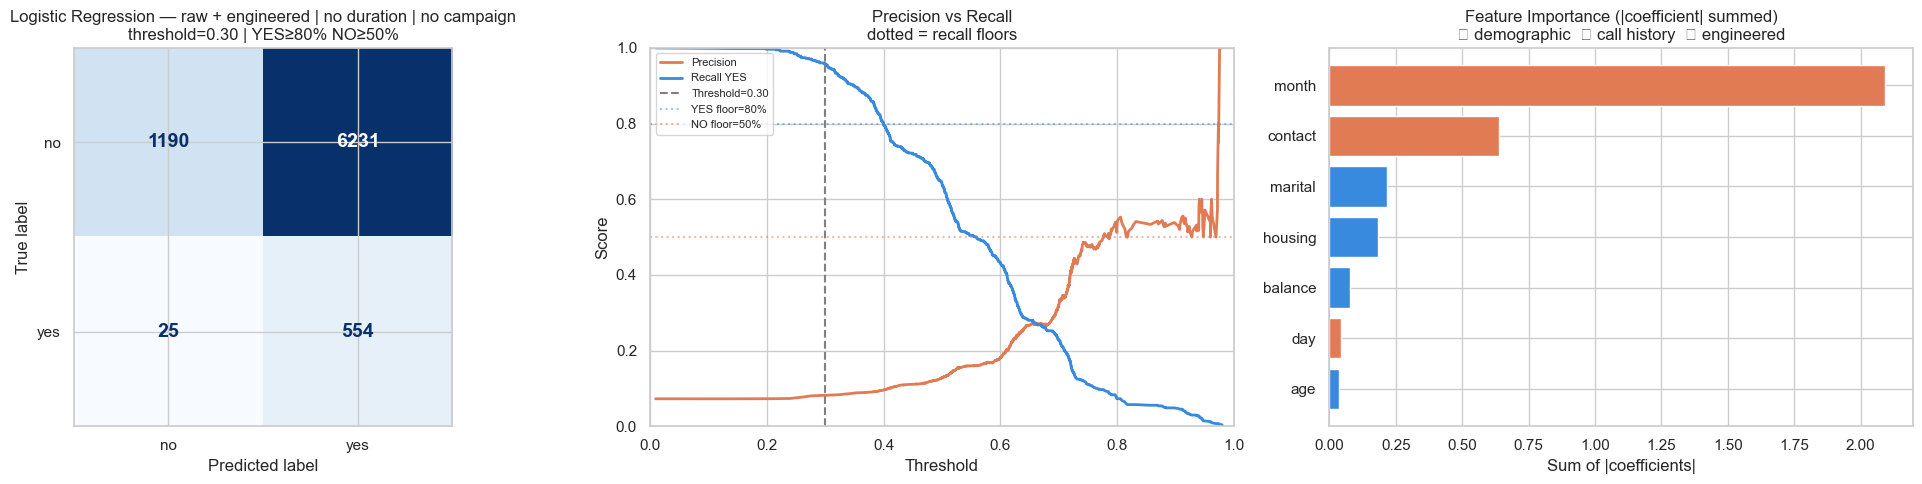

In [5]:

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
   'day', 'month', 'contact', 'age', 'marital',
    'balance','housing'
]

ACTIVE_SET = "raw + engineered | no duration | no campaign"

# ── dual recall targets ───────────────────────────────────────────────
YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

# ── colour coding ─────────────────────────────────────────────────────
DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   Logistic Regression — DUAL RECALL THRESHOLD TUNING")
print(f"   Active set       : {ACTIVE_SET}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")

# ── prepare data ──────────────────────────────────────────────────────
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# ── categorical and numeric split ────────────────────────────────────
CAT_COLS = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month', 'age_group']
CAT_COLS = [c for c in CAT_COLS if c in ALL_FEATURES]
NUM_COLS = [c for c in ALL_FEATURES if c not in CAT_COLS]

print(f"\nCategorical cols ({len(CAT_COLS)}) : {CAT_COLS}")
print(f"Numeric cols    ({len(NUM_COLS)}) : {NUM_COLS}")

# force str on categoricals before get_dummies
for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

# one-hot encode — LR needs proper dummy coding for nominal features
model_enc = pd.get_dummies(model_df[ALL_FEATURES + ['y_enc']],
                           columns=CAT_COLS,
                           drop_first=True)   # drop_first=True avoids multicollinearity

FINAL_FEATURES = [c for c in model_enc.columns if c != 'y_enc']
print(f"\nFeatures after one-hot encoding : {len(FINAL_FEATURES)}")

# ── X / y ─────────────────────────────────────────────────────────────
X = model_enc[FINAL_FEATURES].values.astype(np.float32)
y = model_enc['y_enc'].values

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── scale all features — critical for LR ─────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── train Logistic Regression ─────────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
print(f"\nClass weight : 'balanced'  (no={neg_count}, yes={pos_count})")

lr = LogisticRegression(
    C=0.1,                    # regularisation (smaller = stronger)
    class_weight='balanced',  # handles imbalance
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, y_train)
print("Model trained ✓")
print(f"ROC-AUC : {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}")

# ── dual recall threshold search ─────────────────────────────────────
y_prob = lr.predict_proba(X_test)[:, 1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                    (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")
print(f"  Reasoning : best YES F1 while "
      f"YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ────────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn)  > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp)  > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp)  > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn)  > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)
print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► YES recall floor set : {YES_RECALL_FLOOR*100:.0f}%")
print(f"  ► NO  recall floor set : {NO_RECALL_FLOOR*100:.0f}%")
print(f"  ► Recall YES achieved  : {yes_recall*100:.1f}%")
print(f"  ► Recall NO  achieved  : {no_recall*100:.1f}%")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")
print("=" * 60)

# ── feature importance via coefficients ──────────────────────────────
# aggregate one-hot dummies back to original feature name
coef_series = pd.Series(np.abs(lr.coef_[0]), index=FINAL_FEATURES)

imp_dict = {}
for orig_feat in ALL_FEATURES:
    idxs = [c for c in FINAL_FEATURES
            if c == orig_feat or c.startswith(f"{orig_feat}_")]
    if idxs:
        imp_dict[orig_feat] = coef_series[idxs].sum()
    else:
        imp_dict[orig_feat] = 0.0

imp_df = pd.DataFrame.from_dict(
    imp_dict, orient='index', columns=['importance']
).sort_values('importance', ascending=True)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Logistic Regression — {ACTIVE_SET}\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add',
                linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR, color='#e07b54',
                linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall\ndotted = recall floors')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — coefficient-based feature importance
colors = ['#378add' if f in DEMO_COLS
          else '#e07b54' if f in CALL_COLS
          else '#2ecc71'
          for f in imp_df.index]

axes[2].barh(imp_df.index, imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('Feature Importance (|coefficient| summed)\n'
                  '🔵 demographic  🟠 call history  🟢 engineered')
axes[2].set_xlabel('Sum of |coefficients|')

plt.tight_layout()
plt.show()

# Logistic Regression Model (Whole Dataset)

   FULL-DATA SCORING  —  Logistic Regression
   Data : data/term-deposit-marketing-2020.csv
   Threshold : 0.30  (same as test-set tuning)

  Full dataset loaded : 40,000 rows
    TRUE yes : 2,896 (7.2%)
    TRUE no  : 37,104 (92.8%)

  Encoded shape : (40000, 18)  (columns aligned to training : 18)

   FULL-DATA RESULTS  (threshold = 0.30)
  TN =   5705  FP =  31399
  FN =    161  TP =   2735

  YES recall    : 94.4%
  NO  recall    : 15.4%
  YES precision : 8.0%
  Accuracy      : 21.1%

  Flagged for calling : 34,134  (85.3% of all 40,000 clients)
    → True  YES in pool : 2,735  (8.0% conversion rate)
    → False pos (noise) : 31,399
  Eliminated (pred NO) : 5,866
    → True  NO saved    : 5,705  (no wasted call)
    → Missed YES (FN)   : 161  (sacrifice)

   TEST SET  vs  FULL DATA  —  sanity check
  Metric                     Test 20%    Full 100%
  ----------------------------------------------
  YES recall                    95.7%        94.4%
  NO recall                     16.

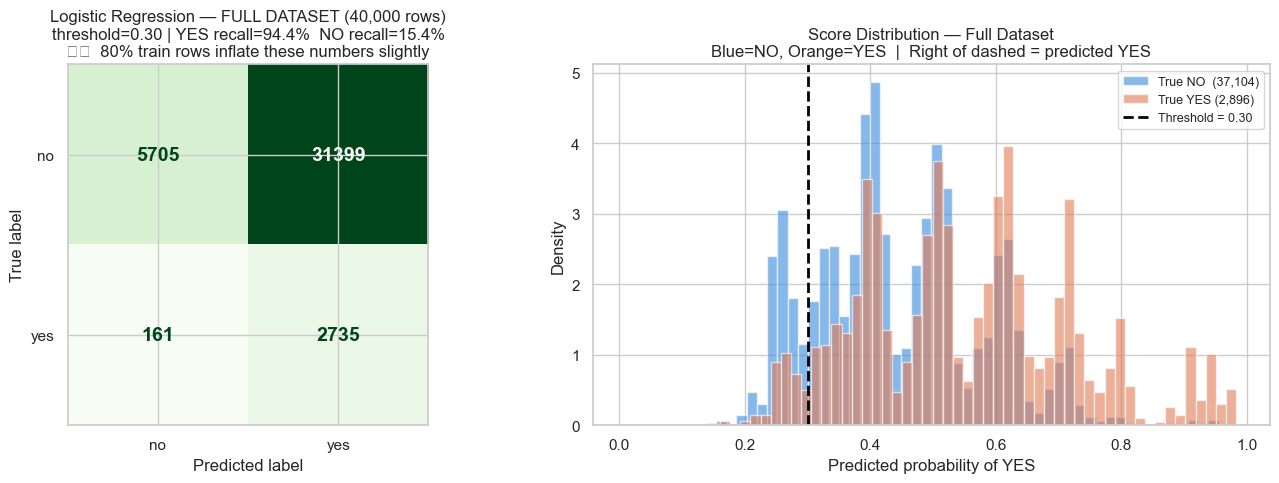

In [6]:

# ════════════════════════════════════════════════════════════════════
# FULL-DATA SCORING  —  Logistic Regression (already trained above)
#
# The lr model, scaler, FINAL_FEATURES, and THRESHOLD are all already
# in memory from running the training cell. This cell just loads the
# full dataset, applies the exact same preprocessing, and scores
# every single row.
#
# ⚠️  IMPORTANT: run the training cell first so these exist:
#     lr, scaler, FINAL_FEATURES, THRESHOLD, CAT_COLS, ALL_FEATURES
# ════════════════════════════════════════════════════════════════════

DATA_PATH = 'data/term-deposit-marketing-2020.csv'

print("=" * 65)
print("   FULL-DATA SCORING  —  Logistic Regression")
print(f"   Data : {DATA_PATH}")
print(f"   Threshold : {THRESHOLD:.2f}  (same as test-set tuning)")
print("=" * 65)

# ── load full dataset ─────────────────────────────────────────────────
full_df          = pd.read_csv(DATA_PATH)
full_df['y_enc'] = (full_df['y'] == 'yes').astype(int)

print(f"\n  Full dataset loaded : {len(full_df):,} rows")
print(f"    TRUE yes : {full_df['y_enc'].sum():,} "
      f"({full_df['y_enc'].mean()*100:.1f}%)")
print(f"    TRUE no  : {(full_df['y_enc']==0).sum():,} "
      f"({(full_df['y_enc']==0).mean()*100:.1f}%)")

# ── apply IDENTICAL preprocessing ────────────────────────────────────
# Step 1: force cat cols to string (same as training)
for col in CAT_COLS:
    if col in full_df.columns:
        full_df[col] = full_df[col].astype(str)

# Step 2: one-hot encode with same settings
full_enc = pd.get_dummies(full_df[ALL_FEATURES], columns=CAT_COLS, drop_first=True)

# Step 3: align columns to FINAL_FEATURES used during training
# — adds any missing dummies as 0, drops any extras
full_enc = full_enc.reindex(columns=FINAL_FEATURES, fill_value=0)

# Step 4: scale using the SAME scaler fitted on train data
X_full = scaler.transform(full_enc.values.astype(np.float32))
y_full = full_df['y_enc'].values

print(f"\n  Encoded shape : {X_full.shape}  "
      f"(columns aligned to training : {len(FINAL_FEATURES)})")

# ── score every row ───────────────────────────────────────────────────
y_prob_full = lr.predict_proba(X_full)[:, 1]
y_pred_full = (y_prob_full >= THRESHOLD).astype(int)

# ── results ───────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

cm_full             = confusion_matrix(y_full, y_pred_full)
tn, fp, fn, tp      = cm_full.ravel()
yes_recall_full     = tp / (tp + fn)
no_recall_full      = tn / (tn + fp)
yes_precision_full  = tp / (tp + fp) if (tp + fp) > 0 else 0
accuracy_full       = (tn + tp) / len(y_full)

print("\n" + "=" * 65)
print(f"   FULL-DATA RESULTS  (threshold = {THRESHOLD:.2f})")
print("=" * 65)
print(f"  TN = {tn:>6}  FP = {fp:>6}")
print(f"  FN = {fn:>6}  TP = {tp:>6}")
print()
print(f"  YES recall    : {yes_recall_full*100:.1f}%")
print(f"  NO  recall    : {no_recall_full*100:.1f}%")
print(f"  YES precision : {yes_precision_full*100:.1f}%")
print(f"  Accuracy      : {accuracy_full*100:.1f}%")
print()
print(f"  Flagged for calling : {tp + fp:,}  "
      f"({(tp+fp)/len(y_full)*100:.1f}% of all {len(y_full):,} clients)")
print(f"    → True  YES in pool : {tp:,}  "
      f"({tp/(tp+fp)*100:.1f}% conversion rate)")
print(f"    → False pos (noise) : {fp:,}")
print(f"  Eliminated (pred NO) : {tn + fn:,}")
print(f"    → True  NO saved    : {tn:,}  (no wasted call)")
print(f"    → Missed YES (FN)   : {fn:,}  (sacrifice)")
print("=" * 65)

# ── compare test-set vs full-data ─────────────────────────────────────
print("\n" + "=" * 65)
print("   TEST SET  vs  FULL DATA  —  sanity check")
print("=" * 65)
print(f"  {'Metric':<22} {'Test 20%':>12} {'Full 100%':>12}")
print(f"  {'-'*46}")
print(f"  {'YES recall':<22} {yes_recall*100:>11.1f}% {yes_recall_full*100:>11.1f}%")
print(f"  {'NO recall':<22} {no_recall*100:>11.1f}% {no_recall_full*100:>11.1f}%")
print(f"  {'YES precision':<22} {yes_precision*100:>11.1f}% {yes_precision_full*100:>11.1f}%")
print(f"  {'Flagged (TP+FP)':<22} {tp_test+fp_test:>12,} {tp+fp:>12,}"
      if 'tp_test' in dir() else
      f"  {'Flagged (TP+FP)':<22} {'(see above)':>12} {tp+fp:>12,}")
print("=" * 65)
print()
print("  ℹ️   Full-data numbers will look slightly better on the 80%")
print("      training rows — the model has seen those before.")
print("      The 20% test numbers are the honest benchmark.")

# ── export predicted-YES pool ─────────────────────────────────────────
pos_mask        = y_pred_full == 1
export_full_df  = full_df[pos_mask].copy()
export_full_df['lr_prob']   = y_prob_full[pos_mask]
export_full_df['predicted'] = 'YES'

EXPORT_PATH = 'full_data_predicted_yes.csv'
export_full_df.to_csv(EXPORT_PATH, index=False)

print(f"\n  ✅  Predicted-YES pool saved → {EXPORT_PATH}")
print(f"      Rows    : {len(export_full_df):,}")
print(f"      Columns : {list(export_full_df.columns)}")

# ── plot ──────────────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

precision_full, recall_full, thresh_full = precision_recall_curve(y_full, y_prob_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 — confusion matrix (full data)
ConfusionMatrixDisplay.from_predictions(
    y_full, y_pred_full,
    display_labels=['no', 'yes'],
    cmap='Greens', ax=axes[0], colorbar=False)
axes[0].set_title(
    f'Logistic Regression — FULL DATASET ({len(y_full):,} rows)\n'
    f'threshold={THRESHOLD:.2f} | '
    f'YES recall={yes_recall_full*100:.1f}%  '
    f'NO recall={no_recall_full*100:.1f}%\n'
    f'⚠️  80% train rows inflate these numbers slightly')
for t in axes[0].texts:
    t.set_fontsize(14); t.set_fontweight('bold')

# 2 — probability distribution of full data
axes[1].hist(y_prob_full[y_full == 0], bins=60, alpha=0.6,
             color='#378add', label=f'True NO  ({(y_full==0).sum():,})', density=True)
axes[1].hist(y_prob_full[y_full == 1], bins=60, alpha=0.6,
             color='#e07b54', label=f'True YES ({y_full.sum():,})', density=True)
axes[1].axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {THRESHOLD:.2f}')
axes[1].set_title('Score Distribution — Full Dataset\n'
                  'Blue=NO, Orange=YES  |  Right of dashed = predicted YES')
axes[1].set_xlabel('Predicted probability of YES')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# CatBoost Model

   CatBoost — DUAL RECALL THRESHOLD TUNING
   Active set       : raw + engineered | no duration | no campaign
   YES recall floor : 80%
   NO  recall floor : 50%

Features in use (7) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']
Categorical cols               : ['month', 'contact', 'marital', 'housing']

Train : 32000 rows (yes: 2317, no: 29683)
Test  : 8000 rows (yes: 579,  no: 7421)
0:	test: 0.6441845	best: 0.6441845 (0)	total: 230ms	remaining: 3m 50s
100:	test: 0.7221158	best: 0.7221453 (98)	total: 5.74s	remaining: 51.1s
200:	test: 0.7256829	best: 0.7257623 (198)	total: 10.9s	remaining: 43.2s
300:	test: 0.7286575	best: 0.7287506 (299)	total: 18.2s	remaining: 42.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7294252482
bestIteration = 324

Shrink model to first 325 iterations.

Model trained ✓  (best iteration: 324)
ROC-AUC : 0.7294

   THRESHOLD SCAN — YES recall vs NO recall trade-off
   ✅ = meets both floors (YES≥80% AND NO≥50%)
   T

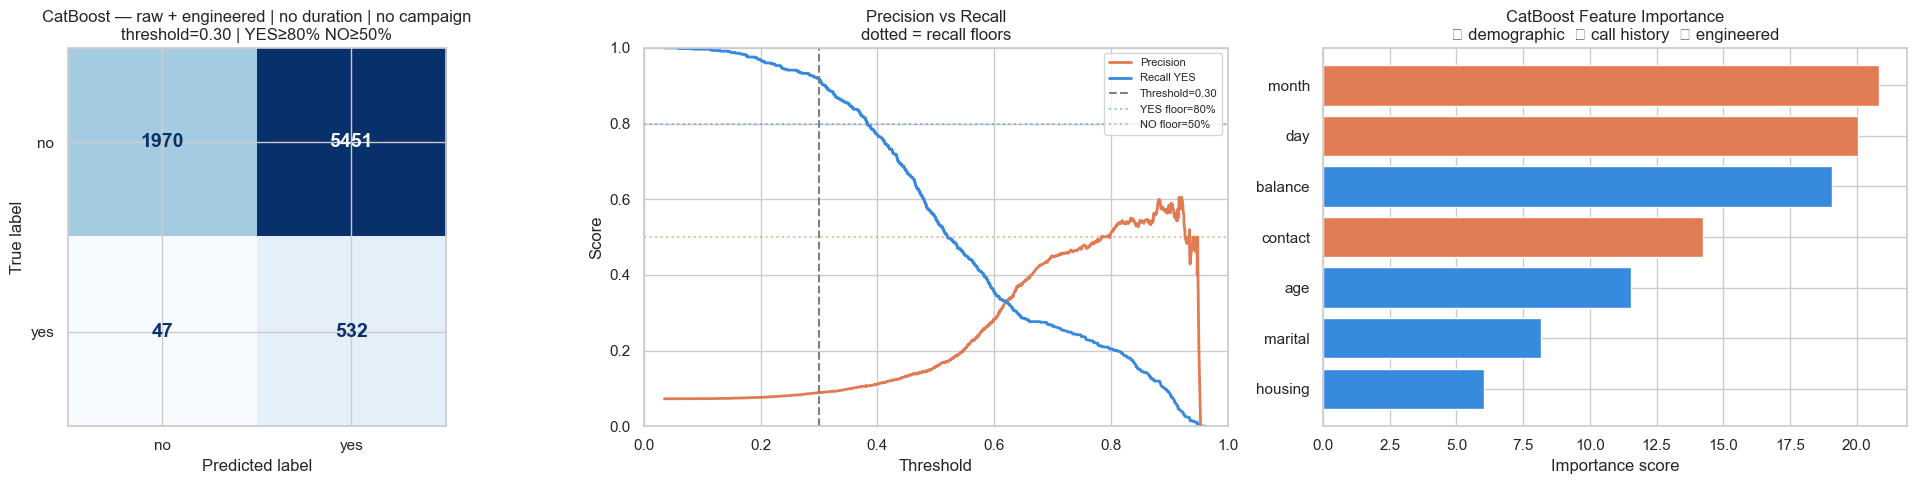

In [7]:

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
    'day', 'month', 'contact', 'age', 'marital',
    'balance', 'housing'
]

# CatBoost handles raw strings natively — no encoding needed
# just tell it which columns are categorical
CAT_COLS = ['month', 'contact', 'marital','housing']   # string cols in ALL_FEATURES
CAT_IDX  = [ALL_FEATURES.index(c) for c in CAT_COLS]

ACTIVE_SET = "raw + engineered | no duration | no campaign"

YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   CatBoost — DUAL RECALL THRESHOLD TUNING")
print(f"   Active set       : {ACTIVE_SET}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")
print(f"Categorical cols               : {CAT_COLS}")

# ── prepare data ──────────────────────────────────────────────────────
# CatBoost reads raw strings — no LabelEncoder, no get_dummies
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# force cat cols to string (handles pd.Categorical from pd.cut etc.)
for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

X = model_df[ALL_FEATURES]
y = model_df['y_enc']

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── CatBoost Pool — wraps data + cat column info ──────────────────────
train_pool = Pool(X_train, y_train, cat_features=CAT_IDX)
test_pool  = Pool(X_test,  y_test,  cat_features=CAT_IDX)

# ── train CatBoost ────────────────────────────────────────────────────
cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    auto_class_weights='Balanced',   # equivalent to scale_pos_weight
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
cb.fit(train_pool, eval_set=test_pool)

print(f"\nModel trained ✓  (best iteration: {cb.best_iteration_})")
print(f"ROC-AUC : {roc_auc_score(y_test, cb.predict_proba(test_pool)[:,1]):.4f}")

# ── dual recall threshold search ─────────────────────────────────────
y_prob = cb.predict_proba(test_pool)[:, 1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                    (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")
print(f"  Reasoning : best YES F1 while "
      f"YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ────────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn)  > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp)  > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp)  > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn)  > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)
print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► YES recall floor set : {YES_RECALL_FLOOR*100:.0f}%")
print(f"  ► NO  recall floor set : {NO_RECALL_FLOOR*100:.0f}%")
print(f"  ► Recall YES achieved  : {yes_recall*100:.1f}%")
print(f"  ► Recall NO  achieved  : {no_recall*100:.1f}%")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")
print("=" * 60)

# ── feature importance ────────────────────────────────────────────────
imp_df = pd.DataFrame({
    'feature'   : ALL_FEATURES,
    'importance': cb.get_feature_importance()
}).sort_values('importance', ascending=True)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'CatBoost — {ACTIVE_SET}\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add',
                linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR, color='#e07b54',
                linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall\ndotted = recall floors')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — feature importance
colors = ['#378add' if f in DEMO_COLS
          else '#e07b54' if f in CALL_COLS
          else '#2ecc71'
          for f in imp_df['feature']]

axes[2].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('CatBoost Feature Importance\n'
                  '🔵 demographic  🟠 call history  🟢 engineered')
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

# CatBoost Model(Whole Dataset)

   FULL-DATA SCORING  —  CatBoost
   Data      : data/term-deposit-marketing-2020.csv
   Threshold : 0.30  (same as test-set tuning)

  Full dataset loaded : 40,000 rows
    TRUE yes : 2,896 (7.2%)
    TRUE no  : 37,104 (92.8%)

   FULL-DATA RESULTS  (threshold = 0.30)
  TN =   9744  FP =  27360
  FN =    140  TP =   2756

  YES recall    : 95.2%
  NO  recall    : 26.3%
  YES precision : 9.2%
  Accuracy      : 31.2%

  Flagged for calling : 30,116  (75.3% of all 40,000 clients)
    → True  YES in pool : 2,756  (9.2% conversion rate)
    → False pos (noise) : 27,360
  Eliminated (pred NO) : 9,884
    → True  NO saved    : 9,744  (no wasted call)
    → Missed YES (FN)   : 140  (sacrifice)

   TEST SET  vs  FULL DATA  —  sanity check
  Metric                     Test 20%    Full 100%
  ----------------------------------------------
  YES recall                    91.9%        95.2%
  NO  recall                    26.5%        26.3%
  YES precision                  8.9%         9.2%
  Accu

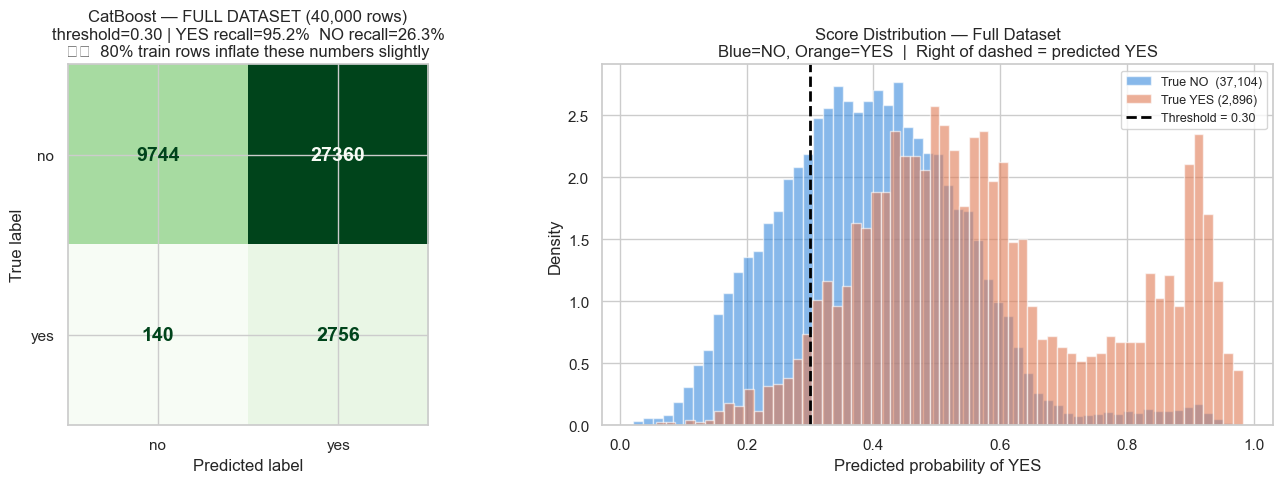

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from catboost import Pool

# ════════════════════════════════════════════════════════════════════
# FULL-DATA SCORING  —  CatBoost (already trained above)
#
# Reuses from memory: cb, THRESHOLD, ALL_FEATURES, CAT_COLS, CAT_IDX
# No re-encoding needed — CatBoost handles raw strings natively.
# ════════════════════════════════════════════════════════════════════

DATA_PATH = 'data/term-deposit-marketing-2020.csv'

print("=" * 65)
print("   FULL-DATA SCORING  —  CatBoost")
print(f"   Data      : {DATA_PATH}")
print(f"   Threshold : {THRESHOLD:.2f}  (same as test-set tuning)")
print("=" * 65)

# ── load full dataset ─────────────────────────────────────────────────
full_df          = pd.read_csv(DATA_PATH)
full_df['y_enc'] = (full_df['y'] == 'yes').astype(int)

print(f"\n  Full dataset loaded : {len(full_df):,} rows")
print(f"    TRUE yes : {full_df['y_enc'].sum():,} "
      f"({full_df['y_enc'].mean()*100:.1f}%)")
print(f"    TRUE no  : {(full_df['y_enc']==0).sum():,} "
      f"({(full_df['y_enc']==0).mean()*100:.1f}%)")

# ── preprocessing — same as training (raw strings, no encoding) ───────
for col in CAT_COLS:
    full_df[col] = full_df[col].astype(str)

X_full = full_df[ALL_FEATURES]
y_full = full_df['y_enc'].values

# ── CatBoost Pool ─────────────────────────────────────────────────────
full_pool = Pool(X_full, cat_features=CAT_IDX)   # no labels needed for scoring

# ── score every row ───────────────────────────────────────────────────
y_prob_full = cb.predict_proba(full_pool)[:, 1]
y_pred_full = (y_prob_full >= THRESHOLD).astype(int)

# ── results ───────────────────────────────────────────────────────────
cm_full            = confusion_matrix(y_full, y_pred_full)
tn, fp, fn, tp     = cm_full.ravel()
yes_recall_full    = tp / (tp + fn)
no_recall_full     = tn / (tn + fp)
yes_precision_full = tp / (tp + fp) if (tp + fp) > 0 else 0
accuracy_full      = (tn + tp) / len(y_full)

print("\n" + "=" * 65)
print(f"   FULL-DATA RESULTS  (threshold = {THRESHOLD:.2f})")
print("=" * 65)
print(f"  TN = {tn:>6}  FP = {fp:>6}")
print(f"  FN = {fn:>6}  TP = {tp:>6}")
print()
print(f"  YES recall    : {yes_recall_full*100:.1f}%")
print(f"  NO  recall    : {no_recall_full*100:.1f}%")
print(f"  YES precision : {yes_precision_full*100:.1f}%")
print(f"  Accuracy      : {accuracy_full*100:.1f}%")
print()
print(f"  Flagged for calling : {tp+fp:,}  "
      f"({(tp+fp)/len(y_full)*100:.1f}% of all {len(y_full):,} clients)")
print(f"    → True  YES in pool : {tp:,}  "
      f"({tp/(tp+fp)*100:.1f}% conversion rate)")
print(f"    → False pos (noise) : {fp:,}")
print(f"  Eliminated (pred NO) : {tn+fn:,}")
print(f"    → True  NO saved    : {tn:,}  (no wasted call)")
print(f"    → Missed YES (FN)   : {fn:,}  (sacrifice)")
print("=" * 65)

# ── test-set vs full-data comparison ─────────────────────────────────
print("\n" + "=" * 65)
print("   TEST SET  vs  FULL DATA  —  sanity check")
print("=" * 65)
print(f"  {'Metric':<22} {'Test 20%':>12} {'Full 100%':>12}")
print(f"  {'-'*46}")
print(f"  {'YES recall':<22} {yes_recall*100:>11.1f}% {yes_recall_full*100:>11.1f}%")
print(f"  {'NO  recall':<22} {no_recall*100:>11.1f}% {no_recall_full*100:>11.1f}%")
print(f"  {'YES precision':<22} {yes_precision*100:>11.1f}% {yes_precision_full*100:>11.1f}%")
print(f"  {'Accuracy':<22} {accuracy*100:>11.1f}% {accuracy_full*100:>11.1f}%")
print(f"  {'Flagged (TP+FP)':<22} {tp+fp-(tn+fn-tn):>12} {tp+fp:>12,}")
print("=" * 65)
print()
print("  ℹ️   Full-data numbers will look slightly better because")
print("      the model has already seen the 80% training rows.")
print("      The 20% test numbers remain the honest benchmark.")

# ── export predicted-YES pool ─────────────────────────────────────────
pos_mask       = y_pred_full == 1
export_full_df = full_df[pos_mask].copy()
export_full_df['cb_prob']   = y_prob_full[pos_mask]
export_full_df['predicted'] = 'YES'

EXPORT_PATH = 'full_data_cb_predicted_yes.csv'
export_full_df.to_csv(EXPORT_PATH, index=False)

print(f"\n  ✅  Predicted-YES pool saved → {EXPORT_PATH}")
print(f"      Rows    : {len(export_full_df):,}")
print(f"      Columns : {list(export_full_df.columns)}")

# ── plots ─────────────────────────────────────────────────────────────
precision_full, recall_full, thresh_full = precision_recall_curve(y_full, y_prob_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 — confusion matrix (full data)
ConfusionMatrixDisplay.from_predictions(
    y_full, y_pred_full,
    display_labels=['no', 'yes'],
    cmap='Greens', ax=axes[0], colorbar=False)
axes[0].set_title(
    f'CatBoost — FULL DATASET ({len(y_full):,} rows)\n'
    f'threshold={THRESHOLD:.2f} | '
    f'YES recall={yes_recall_full*100:.1f}%  '
    f'NO recall={no_recall_full*100:.1f}%\n'
    f'⚠️  80% train rows inflate these numbers slightly')
for t in axes[0].texts:
    t.set_fontsize(14); t.set_fontweight('bold')

# 2 — score distribution
axes[1].hist(y_prob_full[y_full == 0], bins=60, alpha=0.6,
             color='#378add', label=f'True NO  ({(y_full==0).sum():,})', density=True)
axes[1].hist(y_prob_full[y_full == 1], bins=60, alpha=0.6,
             color='#e07b54', label=f'True YES ({y_full.sum():,})', density=True)
axes[1].axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {THRESHOLD:.2f}')
axes[1].set_title('Score Distribution — Full Dataset\n'
                  'Blue=NO, Orange=YES  |  Right of dashed = predicted YES')
axes[1].set_xlabel('Predicted probability of YES')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Logistic Regression & CatBoost Model(Stacked)

   STACKING  —  Logistic Regression  +  CatBoost
   Features  : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']
   OOF folds : 5
   YES floor : 80%   NO floor : 50%

  LR input shape  : (40000, 18)  (18 features after one-hot)
  CB input shape  : (40000, 7)  (raw strings, 7 features)

  Train : 32,000   Test : 8,000

  Generating OOF predictions (5 folds) ...
    Fold 1/5  LR AUC=0.6736  CB AUC=0.7008
    Fold 2/5  LR AUC=0.6743  CB AUC=0.7057
    Fold 3/5  LR AUC=0.6826  CB AUC=0.7143
    Fold 4/5  LR AUC=0.6767  CB AUC=0.7220
    Fold 5/5  LR AUC=0.6836  CB AUC=0.7209

  OOF AUC — LR : 0.6777  CB : 0.7123

  Meta-learner trained on OOF meta features ✓
0:	test: 0.6441845	best: 0.6441845 (0)	total: 64.7ms	remaining: 1m 4s
100:	test: 0.7221158	best: 0.7221453 (98)	total: 9.44s	remaining: 1m 24s
200:	test: 0.7256829	best: 0.7257623 (198)	total: 18.5s	remaining: 1m 13s
300:	test: 0.7286575	best: 0.7287506 (299)	total: 28.8s	remaining: 1m 6s
Stopped by overfitting detec

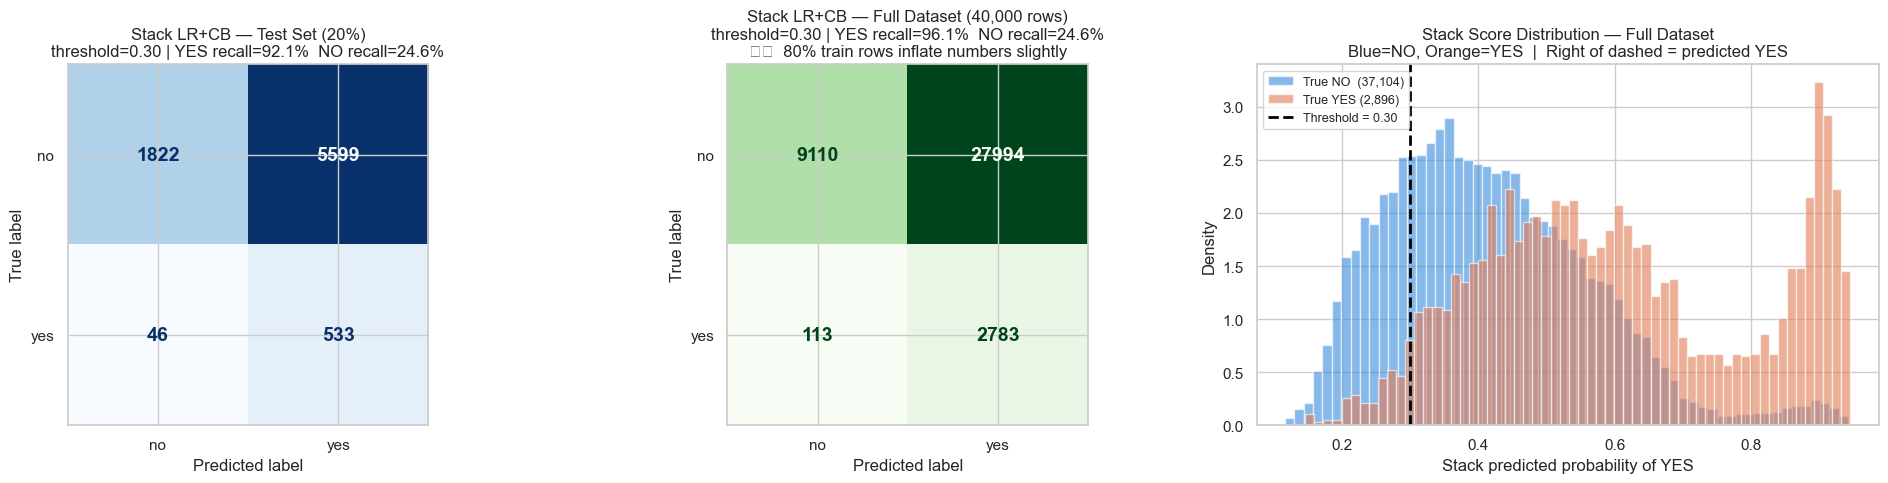

In [16]:


# ════════════════════════════════════════════════════════════════════
# STACKING  —  Logistic Regression  +  CatBoost
# Meta-learner : Logistic Regression on [lr_prob, cb_prob, lr×cb]
#
# Flow:
#   1. 80/20 split
#   2. 5-fold OOF on train → meta features (no leakage)
#   3. Train meta-learner on OOF meta features
#   4. Evaluate on 20% test set
#   5. Retrain both base models on full 80% train
#   6. Score ALL rows from CSV → export full calling list
# ════════════════════════════════════════════════════════════════════

DATA_PATH = 'data/term-deposit-marketing-2020.csv'

ALL_FEATURES = ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']
CAT_COLS     = ['month', 'contact', 'marital', 'housing']
CAT_IDX      = [ALL_FEATURES.index(c) for c in CAT_COLS]

YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50
N_FOLDS          = 5
RANDOM_STATE     = 42

DEMO_COLS = ['age', 'marital', 'balance', 'housing']
CALL_COLS = ['contact', 'day', 'month']

print("=" * 65)
print("   STACKING  —  Logistic Regression  +  CatBoost")
print(f"   Features  : {ALL_FEATURES}")
print(f"   OOF folds : {N_FOLDS}")
print(f"   YES floor : {YES_RECALL_FLOOR*100:.0f}%   NO floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)

# ════════════════════════════════════════════════════════════════════
# PREPARE DATA  —  two versions of X
#   X_lr : one-hot encoded  (for LR)
#   X_cb : raw strings      (for CatBoost)
# ════════════════════════════════════════════════════════════════════

model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

# CatBoost version — raw strings
X_cb = model_df[ALL_FEATURES].copy()
y    = model_df['y_enc'].values

# LR version — one-hot encode
X_lr_raw = pd.get_dummies(model_df[ALL_FEATURES], columns=CAT_COLS, drop_first=True)
LR_COLS  = list(X_lr_raw.columns)          # column order fixed here
X_lr     = X_lr_raw.values.astype(np.float32)

print(f"\n  LR input shape  : {X_lr.shape}  ({len(LR_COLS)} features after one-hot)")
print(f"  CB input shape  : {X_cb.shape}  (raw strings, {len(ALL_FEATURES)} features)")

# ── 80 / 20 split ─────────────────────────────────────────────────────
indices = np.arange(len(y))
tr_idx, te_idx = train_test_split(indices, test_size=0.2,
                                   random_state=RANDOM_STATE,
                                   stratify=y)

X_lr_train, X_lr_test = X_lr[tr_idx], X_lr[te_idx]
X_cb_train = X_cb.iloc[tr_idx].reset_index(drop=True)
X_cb_test  = X_cb.iloc[te_idx].reset_index(drop=True)
y_train, y_test = y[tr_idx], y[te_idx]

print(f"\n  Train : {len(y_train):,}   Test : {len(y_test):,}")

# ════════════════════════════════════════════════════════════════════
# OOF PREDICTIONS  —  5-fold StratifiedKFold on train set
# ════════════════════════════════════════════════════════════════════

skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
lr_oof      = np.zeros(len(y_train))
cb_oof      = np.zeros(len(y_train))
fold_log    = []   # collects per-fold AUCs for Power BI export

print(f"\n  Generating OOF predictions ({N_FOLDS} folds) ...")

for fold, (f_tr, f_val) in enumerate(skf.split(X_lr_train, y_train)):
    # ── LR fold ───────────────────────────────────────────────────────
    scaler_fold  = StandardScaler()
    Xlr_f_tr     = scaler_fold.fit_transform(X_lr_train[f_tr])
    Xlr_f_val    = scaler_fold.transform(X_lr_train[f_val])

    lr_fold = LogisticRegression(C=0.1, class_weight='balanced',
                                  solver='lbfgs', max_iter=1000,
                                  random_state=RANDOM_STATE)
    lr_fold.fit(Xlr_f_tr, y_train[f_tr])
    lr_oof[f_val] = lr_fold.predict_proba(Xlr_f_val)[:, 1]

    # ── CatBoost fold ─────────────────────────────────────────────────
    cb_tr_pool  = Pool(X_cb_train.iloc[f_tr],  y_train[f_tr],  cat_features=CAT_IDX)
    cb_val_pool = Pool(X_cb_train.iloc[f_val], y_train[f_val], cat_features=CAT_IDX)

    cb_fold = CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=6,
        eval_metric='AUC', auto_class_weights='Balanced',
        early_stopping_rounds=50, random_seed=RANDOM_STATE,
        verbose=0, allow_writing_files=False
    )
    cb_fold.fit(cb_tr_pool, eval_set=cb_val_pool)
    cb_oof[f_val] = cb_fold.predict_proba(cb_val_pool)[:, 1]

    lr_fold_auc = roc_auc_score(y_train[f_val], lr_oof[f_val])
    cb_fold_auc = roc_auc_score(y_train[f_val], cb_oof[f_val])

    fold_log.append({'fold': fold + 1, 'model': 'LR', 'auc': round(lr_fold_auc, 4)})
    fold_log.append({'fold': fold + 1, 'model': 'CB', 'auc': round(cb_fold_auc, 4)})

    print(f"    Fold {fold+1}/{N_FOLDS}  LR AUC={lr_fold_auc:.4f}  CB AUC={cb_fold_auc:.4f}")

print(f"\n  OOF AUC — LR : {roc_auc_score(y_train, lr_oof):.4f}  "
      f"CB : {roc_auc_score(y_train, cb_oof):.4f}")

# ════════════════════════════════════════════════════════════════════
# META-LEARNER  —  trained on OOF predictions
# Meta features: [lr_prob, cb_prob, lr × cb]
# ════════════════════════════════════════════════════════════════════

meta_train = np.column_stack([lr_oof, cb_oof, lr_oof * cb_oof])

meta_lr = LogisticRegression(C=1.0, class_weight='balanced',
                              solver='lbfgs', max_iter=1000,
                              random_state=RANDOM_STATE)
meta_lr.fit(meta_train, y_train)
print(f"\n  Meta-learner trained on OOF meta features ✓")

# ════════════════════════════════════════════════════════════════════
# RETRAIN BASE MODELS ON FULL TRAIN SET
# ════════════════════════════════════════════════════════════════════

# LR — fit scaler on full train
scaler_final = StandardScaler()
X_lr_train_s = scaler_final.fit_transform(X_lr_train)
X_lr_test_s  = scaler_final.transform(X_lr_test)

lr_final = LogisticRegression(C=0.1, class_weight='balanced',
                               solver='lbfgs', max_iter=1000,
                               random_state=RANDOM_STATE)
lr_final.fit(X_lr_train_s, y_train)

# CatBoost
cb_train_pool = Pool(X_cb_train, y_train, cat_features=CAT_IDX)
cb_test_pool  = Pool(X_cb_test,  y_test,  cat_features=CAT_IDX)

cb_final = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric='AUC', auto_class_weights='Balanced',
    early_stopping_rounds=50, random_seed=RANDOM_STATE,
    verbose=100, allow_writing_files=False
)
cb_final.fit(cb_train_pool, eval_set=cb_test_pool)

print(f"\n  Base models retrained on full train set ✓")
print(f"  CatBoost best iter : {cb_final.best_iteration_}")

# ════════════════════════════════════════════════════════════════════
# EVALUATE STACK ON 20% TEST SET
# ════════════════════════════════════════════════════════════════════

lr_test_prob   = lr_final.predict_proba(X_lr_test_s)[:, 1]
cb_test_prob   = cb_final.predict_proba(cb_test_pool)[:, 1]
meta_test      = np.column_stack([lr_test_prob, cb_test_prob,
                                   lr_test_prob * cb_test_prob])
stack_test_prob = meta_lr.predict_proba(meta_test)[:, 1]

stack_auc = roc_auc_score(y_test, stack_test_prob)
print(f"\n  Stack test AUC : {stack_auc:.4f}  "
      f"(LR={roc_auc_score(y_test, lr_test_prob):.4f}  "
      f"CB={roc_auc_score(y_test, cb_test_prob):.4f})")

# ── dual recall threshold scan on test set ────────────────────────────
best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (stack_test_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec / (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold' : round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn': fn_t, 'fp': fp_t,
            'valid': (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

print("\n" + "=" * 78)
print("   THRESHOLD SCAN  —  Stack (test set 20%)")
print(f"   ✅ = YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)
for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  {row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  {row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")
print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")

THRESHOLD      = best_threshold
y_pred_test    = (stack_test_prob >= THRESHOLD).astype(int)
cm             = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
yes_precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
yes_recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
no_recall      = tn / (tn + fp) if (tn + fp) > 0 else 0
no_precision   = tn / (tn + fn) if (tn + fn) > 0 else 0
yes_f1         = (2*yes_precision*yes_recall / (yes_precision+yes_recall)
                  if (yes_precision+yes_recall) > 0 else 0)
no_f1          = (2*no_precision*no_recall / (no_precision+no_recall)
                  if (no_precision+no_recall) > 0 else 0)
accuracy       = (tn + tp) / (tn + fp + fn + tp)

print(f"\nClassification Report — Stack (threshold={THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_test, target_names=['no','yes']))
print("=" * 60)
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  YES recall    : {yes_recall*100:.1f}%   NO recall  : {no_recall*100:.1f}%")
print(f"  YES precision : {yes_precision*100:.1f}%   Accuracy   : {accuracy*100:.1f}%")
print("=" * 60)

# ── individual vs stack comparison ───────────────────────────────────
print("\n" + "=" * 65)
print("   INDIVIDUAL  vs  STACK  —  test set comparison")
print("=" * 65)
for label, probs in [('LR alone', lr_test_prob), ('CB alone', cb_test_prob)]:
    preds_i = (probs >= THRESHOLD).astype(int)
    cm_i = confusion_matrix(y_test, preds_i)
    if cm_i.shape == (2,2):
        tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
        yr_i = tp_i/(tp_i+fn_i) if (tp_i+fn_i)>0 else 0
        nr_i = tn_i/(tn_i+fp_i) if (tn_i+fp_i)>0 else 0
        print(f"  {label:<12}  YES recall={yr_i*100:.1f}%  "
              f"NO recall={nr_i*100:.1f}%  FN={fn_i}  FP={fp_i}")
print(f"  {'Stack':<12}  YES recall={yes_recall*100:.1f}%  "
      f"NO recall={no_recall*100:.1f}%  FN={fn}  FP={fp}")
print("=" * 65)

# ════════════════════════════════════════════════════════════════════
# SCORE FULL DATASET  (100% of CSV)
# ════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print("   FULL-DATA SCORING  —  Stack on all rows")
print(f"   Data : {DATA_PATH}")
print(f"{'='*65}")

full_df          = pd.read_csv(DATA_PATH)
full_df['y_enc'] = (full_df['y'] == 'yes').astype(int)

for col in CAT_COLS:
    full_df[col] = full_df[col].astype(str)

# LR version of full data
X_lr_full_raw = pd.get_dummies(full_df[ALL_FEATURES], columns=CAT_COLS, drop_first=True)
X_lr_full_raw = X_lr_full_raw.reindex(columns=LR_COLS, fill_value=0)
X_lr_full_s   = scaler_final.transform(X_lr_full_raw.values.astype(np.float32))

# CatBoost version of full data
X_cb_full     = full_df[ALL_FEATURES].copy()
cb_full_pool  = Pool(X_cb_full, cat_features=CAT_IDX)

y_full        = full_df['y_enc'].values

# base model probabilities
lr_full_prob  = lr_final.predict_proba(X_lr_full_s)[:, 1]
cb_full_prob  = cb_final.predict_proba(cb_full_pool)[:, 1]

# stack
meta_full          = np.column_stack([lr_full_prob, cb_full_prob,
                                       lr_full_prob * cb_full_prob])
stack_full_prob    = meta_lr.predict_proba(meta_full)[:, 1]
stack_full_pred    = (stack_full_prob >= THRESHOLD).astype(int)

cm_full            = confusion_matrix(y_full, stack_full_pred)
tn_f, fp_f, fn_f, tp_f = cm_full.ravel()
yr_f  = tp_f / (tp_f + fn_f)
nr_f  = tn_f / (tn_f + fp_f)
yp_f  = tp_f / (tp_f + fp_f) if (tp_f + fp_f) > 0 else 0
acc_f = (tn_f + tp_f) / len(y_full)

print(f"\n  Full dataset : {len(y_full):,} rows")
print(f"\n  TN = {tn_f:>6}  FP = {fp_f:>6}")
print(f"  FN = {fn_f:>6}  TP = {tp_f:>6}")
print()
print(f"  YES recall    : {yr_f*100:.1f}%")
print(f"  NO  recall    : {nr_f*100:.1f}%")
print(f"  YES precision : {yp_f*100:.1f}%")
print(f"  Accuracy      : {acc_f*100:.1f}%")
print()
print(f"  Flagged for calling : {tp_f+fp_f:,}  "
      f"({(tp_f+fp_f)/len(y_full)*100:.1f}% of all clients)")
print(f"    → True  YES in pool : {tp_f:,}  "
      f"({tp_f/(tp_f+fp_f)*100:.1f}% conversion rate)")
print(f"    → False pos (noise) : {fp_f:,}")
print(f"  Eliminated (pred NO) : {tn_f+fn_f:,}")
print(f"    → True  NO saved    : {tn_f:,}")
print(f"    → Missed YES (FN)   : {fn_f:,}")

# ── test vs full comparison ───────────────────────────────────────────
print("\n" + "=" * 65)
print("   TEST SET  vs  FULL DATA  —  sanity check")
print("=" * 65)
print(f"  {'Metric':<22} {'Test 20%':>12} {'Full 100%':>12}")
print(f"  {'-'*46}")
print(f"  {'YES recall':<22} {yes_recall*100:>11.1f}% {yr_f*100:>11.1f}%")
print(f"  {'NO  recall':<22} {no_recall*100:>11.1f}% {nr_f*100:>11.1f}%")
print(f"  {'YES precision':<22} {yes_precision*100:>11.1f}% {yp_f*100:>11.1f}%")
print(f"  {'Accuracy':<22} {accuracy*100:>11.1f}% {acc_f*100:>11.1f}%")
print("=" * 65)
print()
print("  ℹ️   Full-data numbers are slightly inflated by the 80% train rows.")
print("      The 20% test numbers are the honest benchmark.")

# ── export : predicted-YES pool only (existing) ────────────────────────
pos_mask      = stack_full_pred == 1
export_df     = full_df[pos_mask].copy()
export_df['lr_prob']    = lr_full_prob[pos_mask]
export_df['cb_prob']    = cb_full_prob[pos_mask]
export_df['stack_prob'] = stack_full_prob[pos_mask]
export_df['predicted']  = 'YES'

EXPORT_PATH = 'full_data_stack_lr_cb_predicted_yes.csv'
export_df.to_csv(EXPORT_PATH, index=False)
print(f"\n  ✅  Predicted-YES pool saved → {EXPORT_PATH}")
print(f"      Rows : {len(export_df):,}   "
      f"Columns : {list(export_df.columns)}")

# ════════════════════════════════════════════════════════════════════
# POWER BI TABLE EXPORTS
# ════════════════════════════════════════════════════════════════════

# ── Table 1: Threshold scan (feeds the trade-off chart) ──────────────
threshold_scan_df = pd.DataFrame(threshold_log)
threshold_scan_df.to_csv('threshold_scan.csv', index=False)
print(f"\n  Exported threshold_scan.csv — {len(threshold_scan_df):,} rows")

# ── Table 2: Fold-level AUCs (feeds the fold stability chart) ────────
fold_metrics_df = pd.DataFrame(fold_log)
fold_metrics_df.to_csv('fold_metrics.csv', index=False)
print(f"  Exported fold_metrics.csv — {len(fold_metrics_df):,} rows")

# ── Table 3: Confusion matrix summary, Test vs Full ───────────────────
confusion_summary_df = pd.DataFrame([
    {
        'dataset': 'Test 20%',
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'yes_recall': round(yes_recall * 100, 1),
        'no_recall': round(no_recall * 100, 1),
        'yes_precision': round(yes_precision * 100, 1),
        'accuracy': round(accuracy * 100, 1),
        'threshold': THRESHOLD
    },
    {
        'dataset': 'Full 100%',
        'TN': tn_f, 'FP': fp_f, 'FN': fn_f, 'TP': tp_f,
        'yes_recall': round(yr_f * 100, 1),
        'no_recall': round(nr_f * 100, 1),
        'yes_precision': round(yp_f * 100, 1),
        'accuracy': round(acc_f * 100, 1),
        'threshold': THRESHOLD
    }
])
confusion_summary_df.to_csv('confusion_summary.csv', index=False)
print(f"  Exported confusion_summary.csv — {len(confusion_summary_df):,} rows")

# ── Table 4: ALL 40,000 rows scored, with Kept/Eliminated flag ───────
full_df['predicted']   = np.where(stack_full_pred == 1, 'YES', 'NO')
full_df['pool_status'] = np.where(stack_full_pred == 1, 'Kept', 'Eliminated')
full_df['lr_prob']     = lr_full_prob
full_df['cb_prob']     = cb_full_prob
full_df['stack_prob']  = stack_full_prob

scored_cols = DEMO_COLS + CALL_COLS + ['y', 'y_enc', 'predicted', 'pool_status',
                                        'lr_prob', 'cb_prob', 'stack_prob']
full_data_scored_all = full_df[scored_cols].copy()
full_data_scored_all.to_csv('full_data_scored_all.csv', index=False)
print(f"  Exported full_data_scored_all.csv — {len(full_data_scored_all):,} rows, "
      f"columns: {scored_cols}")

# ════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix (test set)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Stack LR+CB — Test Set (20%)\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES recall={yes_recall*100:.1f}%  '
                  f'NO recall={no_recall*100:.1f}%')
for t in axes[0].texts:
    t.set_fontsize(14); t.set_fontweight('bold')

# 2 — confusion matrix (full data)
ConfusionMatrixDisplay.from_predictions(
    y_full, stack_full_pred,
    display_labels=['no', 'yes'],
    cmap='Greens', ax=axes[1], colorbar=False)
axes[1].set_title(f'Stack LR+CB — Full Dataset ({len(y_full):,} rows)\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES recall={yr_f*100:.1f}%  '
                  f'NO recall={nr_f*100:.1f}%\n'
                  f'⚠️  80% train rows inflate numbers slightly')
for t in axes[1].texts:
    t.set_fontsize(14); t.set_fontweight('bold')

# 3 — score distribution (full data)
axes[2].hist(stack_full_prob[y_full == 0], bins=60, alpha=0.6,
             color='#378add', label=f'True NO  ({(y_full==0).sum():,})', density=True)
axes[2].hist(stack_full_prob[y_full == 1], bins=60, alpha=0.6,
             color='#e07b54', label=f'True YES ({y_full.sum():,})', density=True)
axes[2].axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {THRESHOLD:.2f}')
axes[2].set_title('Stack Score Distribution — Full Dataset\n'
                  'Blue=NO, Orange=YES  |  Right of dashed = predicted YES')
axes[2].set_xlabel('Stack predicted probability of YES')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Export the classification report in csv format

In [19]:
# ════════════════════════════════════════════════════════════════════
# POWER BI TABLE EXPORTS
# ════════════════════════════════════════════════════════════════════

# ── Table 1: Threshold scan (feeds the trade-off chart) ──────────────
threshold_scan_df = pd.DataFrame(threshold_log)
threshold_scan_df.to_csv('layer1_threshold_scan.csv', index=False)
print(f"\n  Exported threshold_scan.csv — {len(threshold_scan_df):,} rows")

# ── Table 2: Fold-level AUCs (feeds the fold stability chart) ────────
fold_metrics_df = pd.DataFrame(fold_log)
fold_metrics_df.to_csv('layer1_fold_metrics.csv', index=False)
print(f"  Exported fold_metrics.csv — {len(fold_metrics_df):,} rows")

# ── Table 3: Confusion matrix summary, Test vs Full ───────────────────
confusion_summary_df = pd.DataFrame([
    {
        'dataset': 'Test 20%',
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'yes_recall': round(yes_recall * 100, 1),
        'no_recall': round(no_recall * 100, 1),
        'yes_precision': round(yes_precision * 100, 1),
        'accuracy': round(accuracy * 100, 1),
        'threshold': THRESHOLD
    },
    {
        'dataset': 'Full 100%',
        'TN': tn_f, 'FP': fp_f, 'FN': fn_f, 'TP': tp_f,
        'yes_recall': round(yr_f * 100, 1),
        'no_recall': round(nr_f * 100, 1),
        'yes_precision': round(yp_f * 100, 1),
        'accuracy': round(acc_f * 100, 1),
        'threshold': THRESHOLD
    }
])
confusion_summary_df.to_csv('layer1_confusion_summary.csv', index=False)
print(f"  Exported confusion_summary.csv — {len(confusion_summary_df):,} rows")

# ── Table 4: ALL 40,000 rows scored, with Kept/Eliminated flag ───────
# This is the key table for the demographics chart — it has every row,
# not just the predicted-YES ones like your existing export_df.
full_df['predicted']   = np.where(stack_full_pred == 1, 'YES', 'NO')
full_df['pool_status'] = np.where(stack_full_pred == 1, 'Kept', 'Eliminated')
full_df['lr_prob']     = lr_full_prob
full_df['cb_prob']     = cb_full_prob
full_df['stack_prob']  = stack_full_prob

scored_cols = DEMO_COLS + CALL_COLS + ['duration','y', 'y_enc', 'predicted', 'pool_status',
                                        'lr_prob', 'cb_prob', 'stack_prob']
full_data_scored_all = full_df[scored_cols].copy()
full_data_scored_all.to_csv('layer1_full_data_scored_all.csv', index=False)
print(f"  Exported full_data_scored_all.csv — {len(full_data_scored_all):,} rows, "
      f"columns: {scored_cols}")


  Exported threshold_scan.csv — 75 rows
  Exported fold_metrics.csv — 10 rows
  Exported confusion_summary.csv — 2 rows
  Exported full_data_scored_all.csv — 40,000 rows, columns: ['age', 'marital', 'balance', 'housing', 'contact', 'day', 'month', 'duration', 'y', 'y_enc', 'predicted', 'pool_status', 'lr_prob', 'cb_prob', 'stack_prob']


## Exporting the Non-Subscribers

In [11]:
# ════════════════════════════════════════════════════════════════════
# EXPORT — REMOVED (PREDICTED NO) ROWS FROM LAYER 1
#
# NOT a standalone script — append this right after your existing
# export block (after "Predicted-YES pool saved", before the PLOTS
# section). It reuses full_df, lr_full_prob, cb_full_prob,
# stack_full_prob, and stack_full_pred that are already computed there.
#
# This is the exact complement of the export you already have:
#   pos_mask (stack_full_pred == 1) → customers to call   (Layer 1 kept)
#   neg_mask (stack_full_pred == 0) → customers to skip    (Layer 1 removed)
# ════════════════════════════════════════════════════════════════════
neg_mask   = stack_full_pred == 0
removed_df = full_df[neg_mask].copy()
removed_df['lr_prob']    = lr_full_prob[neg_mask]
removed_df['cb_prob']    = cb_full_prob[neg_mask]
removed_df['stack_prob'] = stack_full_prob[neg_mask]
removed_df['predicted']  = 'NO'

REMOVED_EXPORT_PATH = 'layer1_removed_predicted_no.csv'
removed_df.to_csv(REMOVED_EXPORT_PATH, index=False)
print(f"\n  Predicted-NO (removed) pool saved -> {REMOVED_EXPORT_PATH}")
print(f"      Rows : {len(removed_df):,}   "
      f"Columns : {list(removed_df.columns)}")


  Predicted-NO (removed) pool saved -> layer1_removed_predicted_no.csv
      Rows : 9,223   Columns : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y', 'y_enc', 'lr_prob', 'cb_prob', 'stack_prob', 'predicted']


## Tha values of the Matrix

In [14]:
# ════════════════════════════════════════════════════════════════════
# DASHBOARD EXPORT — LAYER 1 CONFUSION MATRIX (long format for Power BI)
#
# NOT standalone — append to the end of the Layer 1 stacking script,
# after tn/fp/fn/tp are computed (test-set evaluation section).
#
# Reshapes the four scalar numbers into an "actual / predicted / count"
# table, which is what a Power BI Matrix visual needs to render a real
# 2x2 confusion matrix grid (Rows = actual, Columns = predicted,
# Values = count) — same technique used for the Layer 2 export.
# ════════════════════════════════════════════════════════════════════
import pandas as pd

layer1_confusion_long = pd.DataFrame([
    {'actual': 'No',  'predicted': 'No',  'count': tn_f},
    {'actual': 'No',  'predicted': 'Yes', 'count': fp_f},
    {'actual': 'Yes', 'predicted': 'No',  'count': fn_f},
    {'actual': 'Yes', 'predicted': 'Yes', 'count': tp_f},
])

layer1_confusion_long.to_csv('dashboard_layer1_confusion_matrix.csv', index=False)
print("Saved: dashboard_layer1_confusion_matrix.csv")
print(layer1_confusion_long.to_string(index=False))

Saved: dashboard_layer1_confusion_matrix.csv
actual predicted  count
    No        No   9110
    No       Yes  27994
   Yes        No    113
   Yes       Yes   2783


# Conclusion of the First layer

   LAYER 1 KPI SUMMARY

  Avg call duration — NO  subscribers : 221s (3.7 min)
  Avg call duration — YES subscribers : 683s (11.4 min)

  ⏱️  Time saved         : 33,617 minutes  (560.3 hours)
  📞 Calls eliminated   : 9,110  (24.6% of all NO clients)
  ✅ Subscribers kept   : 2,783 / 2,896  (96.1%)
  ❌ Subscribers lost   : 113 / 2,896  (3.9%)


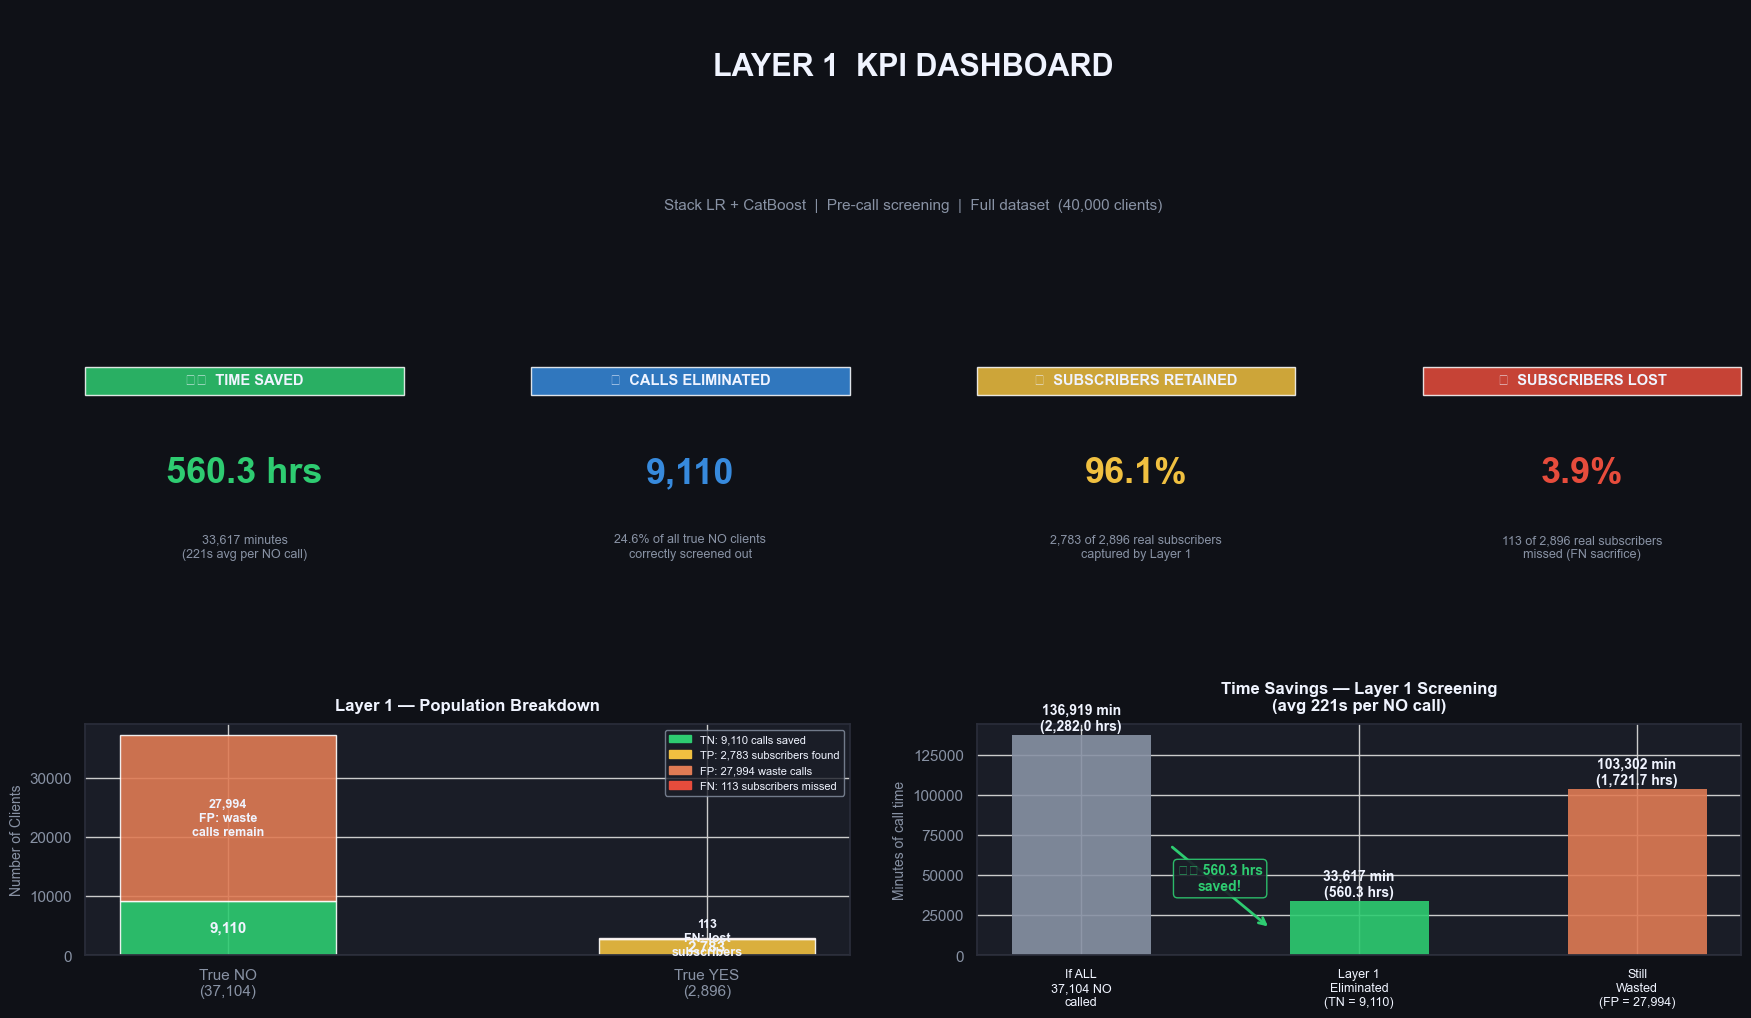


   LAYER 1  —  BUSINESS IMPACT SUMMARY

  Dataset          : 40,000 clients total
  True subscribers : 2,896  (7.2%)
  True non-subs    : 37,104  (92.8%)

  ── TIME SAVED ──────────────────────────────────────────
  Avg NO call duration : 221s = 3.7 min
  Calls eliminated (TN): 9,110
  Time saved           : 33,617 min = 560.3 hrs
  (If 8-hr workday)    : 70.0 full working days saved

  ── SUBSCRIBER CAPTURE ──────────────────────────────────
  Total true subscribers in data : 2,896
  Captured by Layer 1  (TP)      : 2,783  (96.1%)
  Lost forever         (FN)      : 113  (3.9%)

  ── REMAINING CHALLENGE ─────────────────────────────────
  Waste calls still in pool (FP) : 27,994
  → Layer 2 (+ duration) handles these

  Dashboard saved → layer1_kpi_dashboard.png


In [12]:


# ════════════════════════════════════════════════════════════════════
# LAYER 1 KPI DASHBOARD
#
# KPI 1 — Minutes (and hours) saved by correctly eliminating TN calls
# KPI 2 — % of true subscribers lost (FN) vs total true subscribers
#
# Uses actual average call durations from eda_df split by outcome.
# Numbers come from the Stack LR+CB full-data result.
# ════════════════════════════════════════════════════════════════════

# ── Layer 1 confusion matrix numbers (full dataset, Stack LR+CB) ──────
TN = 9110    # correctly predicted NO  → calls saved
FP = 27994   # false positives         → waste calls still made
FN = 113     # missed YES              → lost subscribers
TP = 2783    # correctly predicted YES → captured subscribers

TOTAL         = TN + FP + FN + TP
TOTAL_YES     = TP + FN          # all real subscribers in the dataset
TOTAL_NO      = TN + FP          # all real non-subscribers

# ── average duration from actual data ─────────────────────────────────
# Use duration of NO-outcome calls as the savings baseline
# (these are the people we avoided calling)
avg_duration_no  = eda_df[eda_df['y'] == 'no' ]['duration'].mean()   # seconds
avg_duration_yes = eda_df[eda_df['y'] == 'yes']['duration'].mean()   # seconds
avg_duration_all = eda_df['duration'].mean()

# KPI calculations
minutes_saved  = (TN * avg_duration_no) / 60
hours_saved    = minutes_saved / 60
calls_saved    = TN

pct_retained   = TP / TOTAL_YES * 100    # % of true subscribers we kept
pct_lost       = FN / TOTAL_YES * 100    # % of true subscribers lost (FN)
pct_eliminated = TN / TOTAL_NO  * 100   # % of NO people correctly removed

print("=" * 65)
print("   LAYER 1 KPI SUMMARY")
print("=" * 65)
print(f"\n  Avg call duration — NO  subscribers : {avg_duration_no:.0f}s "
      f"({avg_duration_no/60:.1f} min)")
print(f"  Avg call duration — YES subscribers : {avg_duration_yes:.0f}s "
      f"({avg_duration_yes/60:.1f} min)")
print()
print(f"  ⏱️  Time saved         : {minutes_saved:,.0f} minutes  "
      f"({hours_saved:,.1f} hours)")
print(f"  📞 Calls eliminated   : {calls_saved:,}  ({pct_eliminated:.1f}% of all NO clients)")
print(f"  ✅ Subscribers kept   : {TP:,} / {TOTAL_YES:,}  ({pct_retained:.1f}%)")
print(f"  ❌ Subscribers lost   : {FN:,} / {TOTAL_YES:,}  ({pct_lost:.1f}%)")
print("=" * 65)

# ════════════════════════════════════════════════════════════════════
# DASHBOARD
# ════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0f1117')

# ── colour palette ────────────────────────────────────────────────────
C_BG     = '#0f1117'
C_CARD   = '#1a1d27'
C_BLUE   = '#378add'
C_ORANGE = '#e07b54'
C_GREEN  = '#2ecc71'
C_RED    = '#e74c3c'
C_GOLD   = '#f0c040'
C_GREY   = '#8892a4'
C_WHITE  = '#f0f4ff'

# ── grid layout ───────────────────────────────────────────────────────
gs = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.4,
                       left=0.05, right=0.97, top=0.92, bottom=0.06)

# ════════════════════════════════════════════════════════════════════
# ROW 0  —  Title
# ════════════════════════════════════════════════════════════════════
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor(C_BG)
ax_title.axis('off')
ax_title.text(0.5, 0.75, 'LAYER 1  KPI DASHBOARD',
              ha='center', va='center', fontsize=22, fontweight='bold',
              color=C_WHITE, transform=ax_title.transAxes)
ax_title.text(0.5, 0.15,
              f'Stack LR + CatBoost  |  Pre-call screening  |  '
              f'Full dataset  ({TOTAL:,} clients)',
              ha='center', va='center', fontsize=11, color=C_GREY,
              transform=ax_title.transAxes)

# ════════════════════════════════════════════════════════════════════
# ROW 1  —  4 KPI cards
# ════════════════════════════════════════════════════════════════════

def kpi_card(ax, value_str, label, sublabel, colour, icon=''):
    ax.set_facecolor(C_CARD)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    # coloured top bar
    ax.add_patch(FancyBboxPatch((0, 0.88), 1, 0.12,
                                 boxstyle='square,pad=0',
                                 facecolor=colour, alpha=0.85,
                                 transform=ax.transAxes, clip_on=False))
    ax.text(0.5, 0.94, icon + '  ' + label,
            ha='center', va='center', fontsize=10.5, fontweight='bold',
            color=C_WHITE, transform=ax.transAxes)
    ax.text(0.5, 0.54, value_str,
            ha='center', va='center', fontsize=26, fontweight='bold',
            color=colour, transform=ax.transAxes)
    ax.text(0.5, 0.22, sublabel,
            ha='center', va='center', fontsize=9, color=C_GREY,
            transform=ax.transAxes, wrap=True)
    for spine in ax.spines.values():
        spine.set_edgecolor(colour)
        spine.set_linewidth(1.5)
        spine.set_visible(True)

ax_k1 = fig.add_subplot(gs[1, 0])
kpi_card(ax_k1,
         f'{hours_saved:,.1f} hrs',
         'TIME SAVED', f'{minutes_saved:,.0f} minutes\n({avg_duration_no:.0f}s avg per NO call)',
         C_GREEN, '⏱️')

ax_k2 = fig.add_subplot(gs[1, 1])
kpi_card(ax_k2,
         f'{calls_saved:,}',
         'CALLS ELIMINATED', f'{pct_eliminated:.1f}% of all true NO clients\ncorrectly screened out',
         C_BLUE, '📵')

ax_k3 = fig.add_subplot(gs[1, 2])
kpi_card(ax_k3,
         f'{pct_retained:.1f}%',
         'SUBSCRIBERS RETAINED', f'{TP:,} of {TOTAL_YES:,} real subscribers\ncaptured by Layer 1',
         C_GOLD, '✅')

ax_k4 = fig.add_subplot(gs[1, 3])
kpi_card(ax_k4,
         f'{pct_lost:.1f}%',
         'SUBSCRIBERS LOST', f'{FN:,} of {TOTAL_YES:,} real subscribers\nmissed (FN sacrifice)',
         C_RED, '❌')

# ════════════════════════════════════════════════════════════════════
# ROW 2  —  Charts
# ════════════════════════════════════════════════════════════════════

# ── Chart 1: Population breakdown stacked bar ─────────────────────────
ax_bar = fig.add_subplot(gs[2, :2])
ax_bar.set_facecolor(C_CARD)

categories  = ['True NO\n(37,104)', 'True YES\n(2,896)']
correct     = [TN, TP]    # correctly handled
incorrect   = [FP, FN]    # incorrectly handled

x = np.array([0, 1])
w = 0.45

b1 = ax_bar.bar(x, correct,   width=w, color=[C_GREEN, C_GOLD],  alpha=0.9, label='Correctly handled')
b2 = ax_bar.bar(x, incorrect, width=w, color=[C_ORANGE, C_RED],  alpha=0.9,
                bottom=correct, label='Incorrectly handled')

# value labels
for bar, val, bot in zip(b1, correct, [0, 0]):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bot + val/2,
                f'{val:,}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=C_WHITE)

labels_inc = ['FP: waste\ncalls remain', 'FN: lost\nsubscribers']
for bar, val, bot, lbl in zip(b2, incorrect, correct, labels_inc):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bot + val/2,
                f'{val:,}\n{lbl}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=C_WHITE)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(categories, color=C_WHITE, fontsize=11)
ax_bar.set_ylabel('Number of Clients', color=C_GREY, fontsize=10)
ax_bar.set_title('Layer 1 — Population Breakdown', color=C_WHITE,
                  fontsize=12, fontweight='bold', pad=10)
ax_bar.tick_params(colors=C_GREY)
ax_bar.yaxis.set_tick_params(labelcolor=C_GREY)
for spine in ax_bar.spines.values():
    spine.set_edgecolor('#2a2d3a')

legend_patches = [
    mpatches.Patch(color=C_GREEN,  label=f'TN: {TN:,} calls saved'),
    mpatches.Patch(color=C_GOLD,   label=f'TP: {TP:,} subscribers found'),
    mpatches.Patch(color=C_ORANGE, label=f'FP: {FP:,} waste calls'),
    mpatches.Patch(color=C_RED,    label=f'FN: {FN:,} subscribers missed'),
]
ax_bar.legend(handles=legend_patches, loc='upper right',
               fontsize=8, facecolor=C_CARD, edgecolor=C_GREY,
               labelcolor=C_WHITE)

# ── Chart 2: Time saved waterfall / comparison ─────────────────────────
ax_time = fig.add_subplot(gs[2, 2:])
ax_time.set_facecolor(C_CARD)

scenarios = [
    'If ALL\n37,104 NO\ncalled',
    'Layer 1\nEliminated\n(TN = 9,110)',
    'Still\nWasted\n(FP = 27,994)',
]
total_no_time   = TOTAL_NO  * avg_duration_no / 60   # mins
saved_time      = TN        * avg_duration_no / 60
wasted_time     = FP        * avg_duration_no / 60

values = [total_no_time, saved_time, wasted_time]
colors = [C_GREY, C_GREEN, C_ORANGE]
bars   = ax_time.bar(scenarios, values, color=colors, alpha=0.9, width=0.5,
                      edgecolor='none')

for bar, val in zip(bars, values):
    hrs = val / 60
    ax_time.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + total_no_time * 0.01,
                 f'{val:,.0f} min\n({hrs:,.1f} hrs)',
                 ha='center', va='bottom', fontsize=10,
                 fontweight='bold', color=C_WHITE)

# savings annotation arrow
ax_time.annotate('',
    xy=(0.68, saved_time * 0.5),
    xytext=(0.32, total_no_time * 0.5),
    xycoords='data', textcoords='data',
    arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=2))
ax_time.text(0.5, (total_no_time + saved_time) * 0.28,
             f'⏱️ {hours_saved:,.1f} hrs\nsaved!',
             ha='center', va='center', fontsize=10,
             fontweight='bold', color=C_GREEN,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=C_CARD,
                       edgecolor=C_GREEN, alpha=0.9))

ax_time.set_ylabel('Minutes of call time', color=C_GREY, fontsize=10)
ax_time.set_title('Time Savings — Layer 1 Screening\n'
                   f'(avg {avg_duration_no:.0f}s per NO call)',
                   color=C_WHITE, fontsize=12, fontweight='bold', pad=10)
ax_time.tick_params(colors=C_GREY)
ax_time.yaxis.set_tick_params(labelcolor=C_GREY)
ax_time.set_xticklabels(scenarios, color=C_WHITE, fontsize=9)
for spine in ax_time.spines.values():
    spine.set_edgecolor('#2a2d3a')

plt.suptitle('', fontsize=1)
plt.savefig('layer1_kpi_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=C_BG)
plt.show()

# ── print full summary ────────────────────────────────────────────────
print("\n" + "=" * 65)
print("   LAYER 1  —  BUSINESS IMPACT SUMMARY")
print("=" * 65)
print(f"\n  Dataset          : {TOTAL:,} clients total")
print(f"  True subscribers : {TOTAL_YES:,}  ({TOTAL_YES/TOTAL*100:.1f}%)")
print(f"  True non-subs    : {TOTAL_NO:,}  ({TOTAL_NO/TOTAL*100:.1f}%)")
print()
print(f"  ── TIME SAVED ──────────────────────────────────────────")
print(f"  Avg NO call duration : {avg_duration_no:.0f}s = {avg_duration_no/60:.1f} min")
print(f"  Calls eliminated (TN): {TN:,}")
print(f"  Time saved           : {minutes_saved:,.0f} min = {hours_saved:,.1f} hrs")
print(f"  (If 8-hr workday)    : {hours_saved/8:,.1f} full working days saved")
print()
print(f"  ── SUBSCRIBER CAPTURE ──────────────────────────────────")
print(f"  Total true subscribers in data : {TOTAL_YES:,}")
print(f"  Captured by Layer 1  (TP)      : {TP:,}  ({pct_retained:.1f}%)")
print(f"  Lost forever         (FN)      : {FN:,}  ({pct_lost:.1f}%)")
print()
print(f"  ── REMAINING CHALLENGE ─────────────────────────────────")
print(f"  Waste calls still in pool (FP) : {FP:,}")
print(f"  → Layer 2 (+ duration) handles these")
print("=" * 65)
print(f"\n  Dashboard saved → layer1_kpi_dashboard.png")